# Stratégies — Trend following & signal SMA + VIX

Notebook de travail regroupant trois stratégies existantes et un **nouveau signal de trend
following filtré par le VIX**.

Principe transversal important : **le signal de tendance se calcule toujours sur l'indice
sous-jacent, jamais directement sur le prix de l'ETF à effet de levier.**
Pour **QLD (2×)** et **TQQQ (3×)**, le sous-jacent est le **Nasdaq-100 (`^NDX`)**. Le reset
quotidien du levier rend le prix de l'ETF bruité et path-dependent : on décide « dedans / dehors »
sur l'indice propre, puis on applique la position aux rendements de l'ETF.

Stratégies couvertes :
1. **TQQQ trend following** (SMA sur ^NDX)
2. **QLD trend following** (SMA sur ^NDX)
3. **Top-1** (plus grande capitalisation du S&P 500, basket équipondéré)
4. **Nouveau signal SMA + VIX** : binaire *et* continu (incréments de 0,1) pour le *sizing*.

> Rendement passé ≠ rendement futur. Cash hors marché = 0 %. Signaux décalés d'1 jour (pas de look-ahead).

## 1. Imports & configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

START = "1990-01-01"
INDEX = "^NDX"      # Nasdaq-100 : sous-jacent de QLD & TQQQ
VIX   = "^VIX"      # indice de volatilité implicite (CBOE)
AF    = 252         # jours de bourse / an

plt.rcParams["figure.figsize"] = (13, 6)
pd.options.display.float_format = lambda x: f"{x:,.4f}"

## 2. Chargement des données

Prix ajustés (splits + dividendes) via yfinance pour l'indice, le VIX et les ETF.
Le Top-1 est rechargé depuis le backtest déjà calculé (`results/top1_equalweight.csv`).

In [2]:
CACHE = {"^NDX": "data_cache/ndx.csv", "^VIX": "data_cache/vix.csv",
         "QLD": "data_cache/qld.csv", "TQQQ": "data_cache/tqqq.csv"}

def get_price(ticker, start=START):
    """Série de clôtures ajustées. Lit un cache CSV local si présent (yfinance
    peut renvoyer du vide dans le kernel Jupyter : conflit event-loop), sinon
    télécharge et met en cache."""
    path = CACHE.get(ticker)
    if path and os.path.exists(path):
        return pd.read_csv(path, parse_dates=["date"]).set_index("date")["close"].dropna()
    s = yf.download(ticker, start=start, auto_adjust=True, progress=False)["Close"]
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    s = s.dropna()
    if path:
        os.makedirs("data_cache", exist_ok=True)
        s.to_csv(path, index_label="date", header=["close"])
    return s

ndx  = get_price(INDEX)
vix  = get_price(VIX)
qld  = get_price("QLD")
tqqq = get_price("TQQQ")
top1 = pd.read_csv("results/top1_equalweight.csv", parse_dates=["date"]) \
         .set_index("date")["equity"]

for name, s in [("^NDX", ndx), ("^VIX", vix), ("QLD", qld), ("TQQQ", tqqq), ("Top-1", top1)]:
    print(f"{name:6s} {len(s):5d} pts  {s.index.min().date()} -> {s.index.max().date()}")

^NDX    9192 pts  1990-01-02 -> 2026-07-02
^VIX    9193 pts  1990-01-02 -> 2026-07-02
QLD     5039 pts  2006-06-21 -> 2026-07-02
TQQQ    4122 pts  2010-02-11 -> 2026-07-02
Top-1   9192 pts  1990-01-02 -> 2026-07-02


## 3. Briques réutilisables : signaux, timing, métriques

- `trend_following` : règle SMA de Faber (long si prix > SMA, sinon cash), calculée sur la série passée.
- `align` : projette une série (indice) sur le calendrier d'une autre (ETF).
- `apply_timing` : applique une position (décalée d'1 jour) aux rendements du prix tradé.
- `stats` : total, CAGR, Sharpe, max drawdown.

In [3]:
SMA_TREND = 200

def trend_following(price, window=SMA_TREND):
    """Position 0/1 : long quand price > SMA(window). Calculé sur `price`."""
    sma = price.rolling(window).mean()
    return (price > sma).astype(float)

def align(index_price, target_index):
    """Aligne une série (ex: ^NDX) sur le calendrier d'une autre (ex: TQQQ)."""
    return index_price.reindex(target_index, method="ffill")

def apply_timing(price, position):
    """Équity de trading `price` avec une position décalée d'1 jour (pas de look-ahead).
    `position` peut être fractionnaire (sizing continu)."""
    ret = price.pct_change().fillna(0.0)
    pos = position.reindex(price.index).shift(1).fillna(0.0)
    equity = (1.0 + pos * ret).cumprod()
    return equity / equity.iloc[0], pos

def stats(equity, label):
    total = equity.iloc[-1] / equity.iloc[0] - 1
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr  = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1
    r = equity.pct_change().dropna()
    sharpe = (r.mean() / r.std()) * np.sqrt(AF) if r.std() > 0 else float("nan")
    mdd = (equity / equity.cummax() - 1).min()
    print(f"{label:34s} total:{total:>10.1%}  CAGR:{cagr:>6.2%}  Sharpe:{sharpe:>5.2f}  maxDD:{mdd:>7.1%}")
    return dict(total=total, cagr=cagr, sharpe=sharpe, mdd=mdd)

## 4. TQQQ — trend following (signal sur ^NDX)

Le signal SMA200 est calculé sur le **Nasdaq-100**, puis appliqué aux rendements de **TQQQ (3×)**.

TQQQ Buy & Hold                    total:  35497.2%  CAGR:43.12%  Sharpe: 0.90  maxDD: -81.7%
TQQQ Trend (SMA200 on ^NDX)        total:   9490.1%  CAGR:32.11%  Sharpe: 0.85  maxDD: -54.8%
Temps en marché: 80%


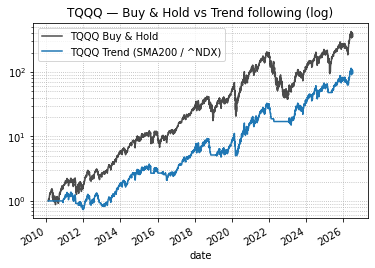

In [4]:
tqqq_idx = align(ndx, tqqq.index)              # ^NDX sur le calendrier TQQQ
tqqq_trend_eq, tqqq_pos = apply_timing(tqqq, trend_following(tqqq_idx))

stats(tqqq / tqqq.iloc[0], "TQQQ Buy & Hold")
stats(tqqq_trend_eq,       "TQQQ Trend (SMA200 on ^NDX)")
print(f"Temps en marché: {tqqq_pos.mean():.0%}")

ax = (tqqq / tqqq.iloc[0]).plot(logy=True, label="TQQQ Buy & Hold", color="black", alpha=.7)
tqqq_trend_eq.plot(ax=ax, label="TQQQ Trend (SMA200 / ^NDX)")
ax.set_title("TQQQ — Buy & Hold vs Trend following (log)"); ax.legend(); ax.grid(True, which="both", ls=":");

## 5. QLD — trend following (signal sur ^NDX)

Idem pour **QLD (2×)** : signal SMA200 sur le Nasdaq-100, appliqué aux rendements de QLD.

QLD Buy & Hold                     total:   9120.4%  CAGR:25.34%  Sharpe: 0.74  maxDD: -83.1%
QLD Trend (SMA200 on ^NDX)         total:   4670.4%  CAGR:21.28%  Sharpe: 0.79  maxDD: -45.3%
Temps en marché: 77%


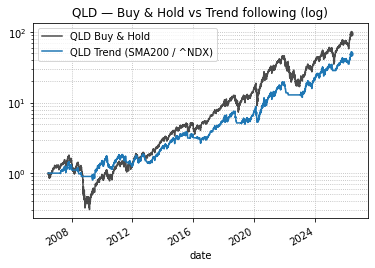

In [5]:
qld_idx = align(ndx, qld.index)
qld_trend_eq, qld_pos = apply_timing(qld, trend_following(qld_idx))

stats(qld / qld.iloc[0], "QLD Buy & Hold")
stats(qld_trend_eq,      "QLD Trend (SMA200 on ^NDX)")
print(f"Temps en marché: {qld_pos.mean():.0%}")

ax = (qld / qld.iloc[0]).plot(logy=True, label="QLD Buy & Hold", color="black", alpha=.7)
qld_trend_eq.plot(ax=ax, label="QLD Trend (SMA200 / ^NDX)")
ax.set_title("QLD — Buy & Hold vs Trend following (log)"); ax.legend(); ax.grid(True, which="both", ls=":");

## 6. Top-1 — plus grande capitalisation du S&P 500

Ici le sous-jacent *est* le basket lui-même : le signal de tendance se calcule directement
sur son équity (aucun ETF à effet de levier n'intervient).

Top-1 Buy & Hold                   total:  23659.8%  CAGR:16.17%  Sharpe: 0.66  maxDD: -77.1%
Top-1 Trend (SMA200)               total:   6400.8%  CAGR:12.12%  Sharpe: 0.64  maxDD: -42.4%
Temps en marché: 70%


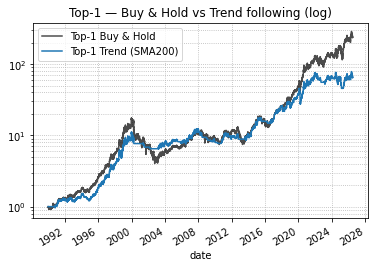

In [6]:
top1_trend_eq, top1_pos = apply_timing(top1, trend_following(top1))

stats(top1 / top1.iloc[0], "Top-1 Buy & Hold")
stats(top1_trend_eq,       "Top-1 Trend (SMA200)")
print(f"Temps en marché: {top1_pos.mean():.0%}")

ax = (top1 / top1.iloc[0]).plot(logy=True, label="Top-1 Buy & Hold", color="black", alpha=.7)
top1_trend_eq.plot(ax=ax, label="Top-1 Trend (SMA200)")
ax.set_title("Top-1 — Buy & Hold vs Trend following (log)"); ax.legend(); ax.grid(True, which="both", ls=":");

## 7. Nouveau signal : trend following **SMA + VIX**

Idée : la SMA seule génère du bruit (faux signaux quand le prix oscille autour de la moyenne).
Le **VIX** (volatilité implicite) est un filtre de régime complémentaire : les cassures de tendance
et les krachs s'accompagnent presque toujours d'une **explosion du VIX**. On l'utilise pour :

1. **Confirmer** la tendance → réduit le bruit (on n'est long que si tendance *et* volatilité maîtrisée).
2. **Doser** l'exposition → plus le VIX est bas, plus la position est grande.

On produit **deux signaux** alignés jour par jour :

- **Signal binaire** `sig_bin ∈ {0, 1}` : long si `prix > SMA(n)` **ET** `VIX < VIX_HIGH`.
- **Signal continu** `sig_cont ∈ {0.0, 0.1, …, 1.0}` (incréments de 0,1, recalculé chaque jour) :

  ```
  gate      = 1 si prix > SMA(n) sinon 0            # porte de tendance
  vix_scale = clip( (VIX_HIGH - VIX) / (VIX_HIGH - VIX_LOW), 0, 1 )
  sig_cont  = round( gate * vix_scale * 10 ) / 10   # arrondi au 0,1
  ```

  Le VIX bougeant tous les jours, `sig_cont` peut changer quotidiennement → parfait pour piloter
  la **taille de position**. `sig_cont` est directement réutilisable comme position fractionnaire.

Paramètres : `SMA=200`, `VIX_LOW=16` (plein risque en dessous), `VIX_HIGH=32` (hors marché au-dessus).

In [7]:
VIX_LOW, VIX_HIGH = 16.0, 32.0

def sma_vix_signal(price, vix_series, window=SMA_TREND, vix_low=VIX_LOW, vix_high=VIX_HIGH):
    """Retourne un DataFrame avec:
       - sig_bin  : signal binaire {0,1}
       - sig_cont : signal continu {0.0,0.1,...,1.0} (sizing), recalculé chaque jour.
    `price` et `vix_series` sont calculés sur le sous-jacent (indice), pas l'ETF."""
    v = vix_series.reindex(price.index, method="ffill")
    sma = price.rolling(window).mean()
    gate = (price > sma).astype(float)                       # porte de tendance

    sig_bin = (gate.astype(bool) & (v < vix_high)).astype(float)

    vix_scale = ((vix_high - v) / (vix_high - vix_low)).clip(0.0, 1.0)
    sig_cont = np.round(gate * vix_scale * 10) / 10.0        # incréments de 0,1

    return pd.DataFrame({"sig_bin": sig_bin, "sig_cont": sig_cont,
                         "vix": v, "sma": sma, "price": price})

# Aperçu sur le Nasdaq-100
sig_ndx = sma_vix_signal(ndx, vix)
sig_ndx[["price", "sma", "vix", "sig_bin", "sig_cont"]].tail(8)

,price,sma,vix,sig_bin,sig_cont
date,,,,,
2026-06-23,"29,347.2695","25,895.0914",19.4900,1.0000,0.8000
2026-06-24,"29,220.0605","25,922.9295",18.6300,1.0000,0.8000
2026-06-25,"29,440.3203","25,951.3196",18.8900,1.0000,0.8000
2026-06-26,"29,118.2402","25,977.7118",18.4100,1.0000,0.8000
2026-06-29,"29,774.7500","26,007.3392",17.6500,1.0000,0.9000
2026-06-30,"30,276.3496","26,038.7582",16.4500,1.0000,1.0000
2026-07-01,"29,809.1309","26,067.3429",16.5900,1.0000,1.0000
2026-07-02,"29,329.2109","26,092.5200",16.1500,1.0000,1.0000


### Distribution du signal continu

Vérifie qu'on obtient bien des paliers de 0,1 qui varient dans le temps.

Répartition des niveaux de sizing (part des jours):
sig_cont
0.0000   0.2690
0.1000   0.0080
0.2000   0.0120
0.3000   0.0130
0.4000   0.0220
0.5000   0.0290
0.6000   0.0410
0.7000   0.0550
0.8000   0.0680
0.9000   0.0810
1.0000   0.4020
Name: count, dtype: float64


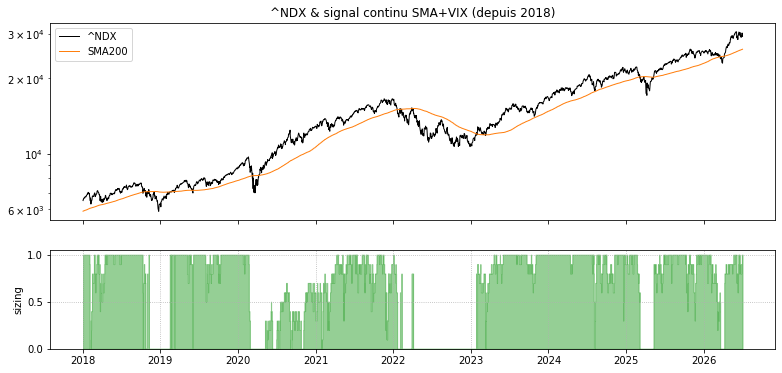

In [8]:
counts = sig_ndx["sig_cont"].value_counts().sort_index()
print("Répartition des niveaux de sizing (part des jours):")
print((counts / counts.sum()).round(3))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True, height_ratios=[2, 1])
recent = sig_ndx.loc["2018":]
a1.plot(recent.index, recent["price"], label="^NDX", color="black", lw=1)
a1.plot(recent.index, recent["sma"], label=f"SMA{SMA_TREND}", color="tab:orange", lw=1)
a1.set_yscale("log"); a1.legend(); a1.set_title("^NDX & signal continu SMA+VIX (depuis 2018)")
a2.fill_between(recent.index, recent["sig_cont"], step="pre", alpha=.5, color="tab:green")
a2.set_ylabel("sizing"); a2.set_ylim(0, 1.05); a2.grid(True, ls=":");

## 8. Backtest du nouveau signal SMA + VIX

Signal calculé sur le **sous-jacent** (^NDX pour QLD/TQQQ ; l'équity Top-1 pour Top-1, avec son propre
VIX de marché) puis appliqué aux rendements de l'actif tradé. On compare, pour chaque actif :
**Buy & Hold**, **Trend SMA200 seul**, **SMA+VIX binaire**, **SMA+VIX continu (sizing)**.

In [9]:
def backtest_sma_vix(asset_price, signal_underlying, vix_series, label):
    """asset_price      : ce qu'on trade (ETF ou basket)
       signal_underlying: série sur laquelle on calcule le signal (indice)
       vix_series       : VIX (filtre de régime)"""
    su = align(signal_underlying, asset_price.index)
    sig = sma_vix_signal(su, vix_series)

    bh = asset_price / asset_price.iloc[0]
    trend_eq, _ = apply_timing(asset_price, trend_following(su))
    bin_eq,  _  = apply_timing(asset_price, sig["sig_bin"])
    cont_eq, cont_pos = apply_timing(asset_price, sig["sig_cont"])

    print(f"\n=== {label} ===")
    stats(bh,       f"{label} Buy & Hold")
    stats(trend_eq, f"{label} Trend SMA200")
    stats(bin_eq,   f"{label} SMA+VIX binaire")
    stats(cont_eq,  f"{label} SMA+VIX continu")
    print(f"Exposition moyenne (continu): {cont_pos.mean():.0%}")

    return dict(bh=bh, trend=trend_eq, binary=bin_eq, cont=cont_eq)

res_tqqq = backtest_sma_vix(tqqq, ndx, vix, "TQQQ")
res_qld  = backtest_sma_vix(qld,  ndx, vix, "QLD")
res_top1 = backtest_sma_vix(top1, top1, vix, "Top-1")


=== TQQQ ===
TQQQ Buy & Hold                    total:  35497.2%  CAGR:43.12%  Sharpe: 0.90  maxDD: -81.7%
TQQQ Trend SMA200                  total:   9490.1%  CAGR:32.11%  Sharpe: 0.85  maxDD: -54.8%
TQQQ SMA+VIX binaire               total:   5766.2%  CAGR:28.21%  Sharpe: 0.79  maxDD: -54.2%
TQQQ SMA+VIX continu               total:   2751.4%  CAGR:22.69%  Sharpe: 0.75  maxDD: -48.2%
Exposition moyenne (continu): 70%

=== QLD ===
QLD Buy & Hold                     total:   9120.4%  CAGR:25.34%  Sharpe: 0.74  maxDD: -83.1%
QLD Trend SMA200                   total:   4670.4%  CAGR:21.28%  Sharpe: 0.79  maxDD: -45.3%
QLD SMA+VIX binaire                total:   3171.9%  CAGR:19.02%  Sharpe: 0.75  maxDD: -47.5%
QLD SMA+VIX continu                total:   1395.1%  CAGR:14.46%  Sharpe: 0.71  maxDD: -35.3%
Exposition moyenne (continu): 64%

=== Top-1 ===
Top-1 Buy & Hold                   total:  23659.8%  CAGR:16.17%  Sharpe: 0.66  maxDD: -77.1%
Top-1 Trend SMA200                 total:   

### Comparaison graphique (TQQQ)

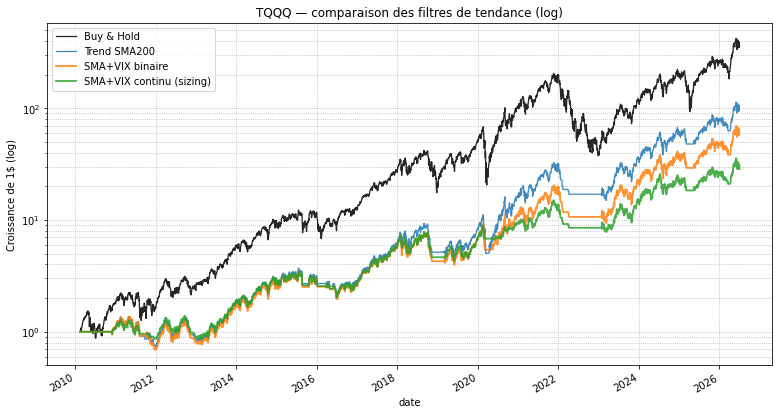

In [10]:
fig, ax = plt.subplots(figsize=(13, 7))
for k, lbl, c in [("bh", "Buy & Hold", "black"),
                  ("trend", "Trend SMA200", "tab:blue"),
                  ("binary", "SMA+VIX binaire", "tab:orange"),
                  ("cont", "SMA+VIX continu (sizing)", "tab:green")]:
    res_tqqq[k].plot(ax=ax, label=lbl, color=c, alpha=.85,
                     lw=1.8 if k in ("cont", "binary") else 1.3)
ax.set_yscale("log"); ax.set_title("TQQQ — comparaison des filtres de tendance (log)")
ax.set_ylabel("Croissance de 1$ (log)"); ax.legend(loc="upper left")
ax.grid(True, which="both", ls=":");

## 9. Pistes

- Le signal **continu** réutilise directement `sig_cont` comme taille de position : on peut le brancher
  sur un moteur de portefeuille (capital initial + DCA) comme dans la page de backtest interactive.
- Paramètres à explorer : fenêtre SMA, bornes VIX (`VIX_LOW`/`VIX_HIGH`), pente de la SMA, VIX vs sa propre moyenne.
- Combiner les trois actifs (TQQQ / QLD / Top-1) dans un portefeuille piloté par `sig_cont`.